# DFT atom

In [1]:
using Pkg;
Pkg.activate("../.");

using SchrodingerEquationSolver
using SchrodingerEquationSolver:   Potentials, MathUtils, Hydrogen, InitialConditions,
                                   IntegralNumericalMethods,
                                   EigenvalueFinders, AtomicBasisSets
import ..OneDSchrodingerEquationSolver.solver_uniform_integer_grid as solver
using Plots
using CSV
using DataFrames
using PrettyTables
using Libxc
using JSON3

  Activating project at `~/Desktop/physics_coding_projects/julia/SchrodingerEquationSolver`


E_min= 0.44170854271356785 E_max= 0.4834170854271357
E= 0.5000000000001597
E_min= 1.4427135678391956 E_max= 1.4844221105527637
E= 1.5000000000004725
E_min= 2.4437185929648235 E_max= 2.4854271356783912
E= 2.500000000000797
E_min= 3.4447236180904515 E_max= 3.486432160804019
E= 3.5000000000011138
E_min= 4.44572864321608 E_max= 4.487437185929648
E= 4.5000000000014175
E_min= 5.446733668341708 E_max= 5.4884422110552755
E= 5.500000000001747
E_min= 6.447738693467336 E_max= 6.4894472361809035
E= 6.50000000000206
E_min= 7.448743718592964 E_max= 7.490452261306531
E= 7.50000000000238
E_min= 8.449748743718592 E_max= 8.49145728643216
E= 8.500000000002679


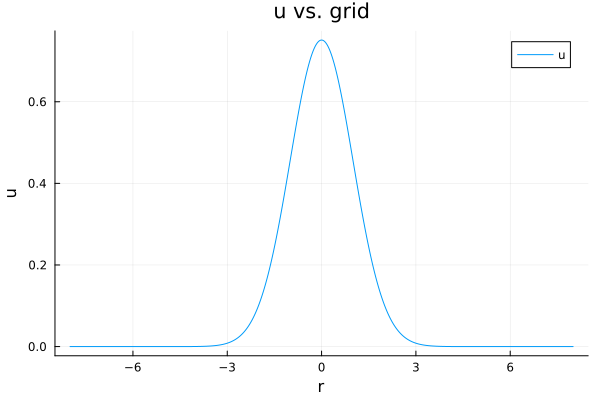

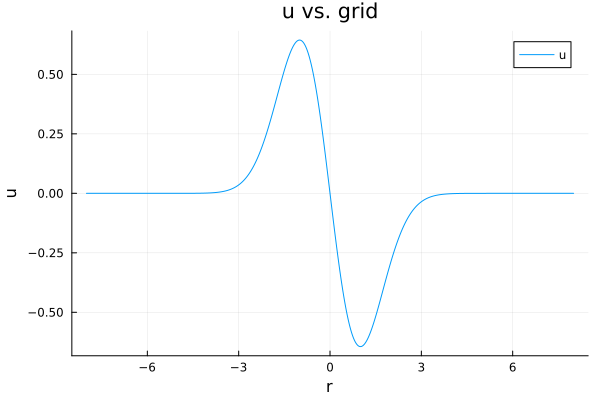

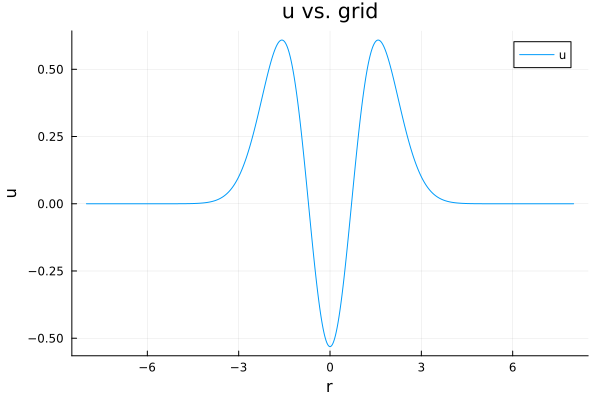

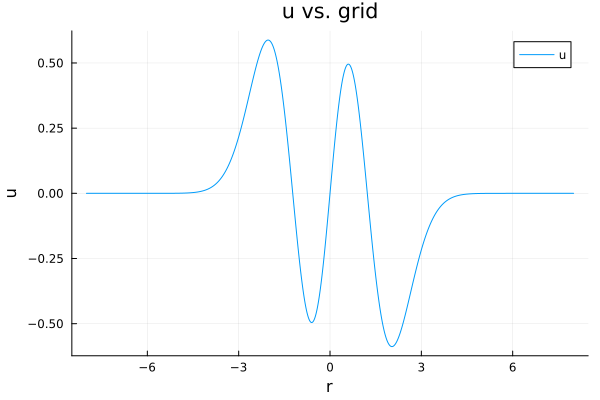

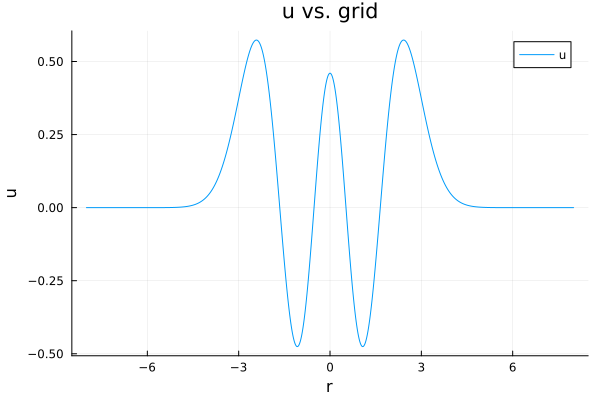

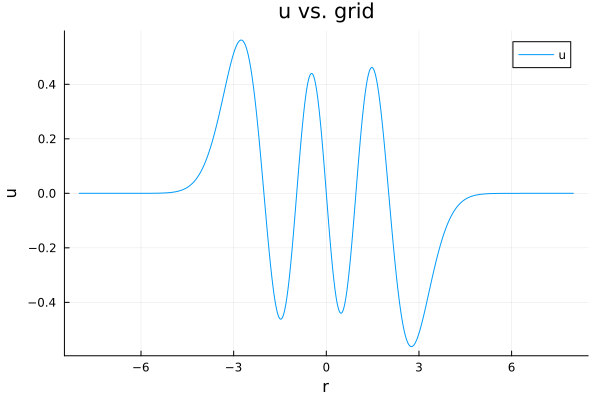

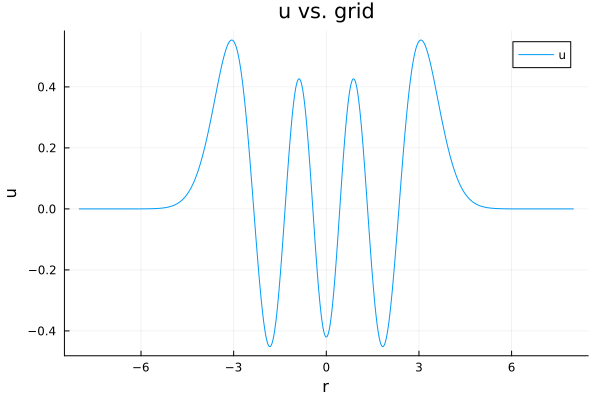

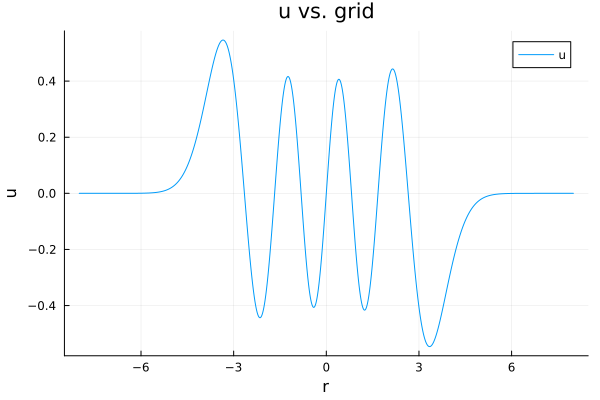

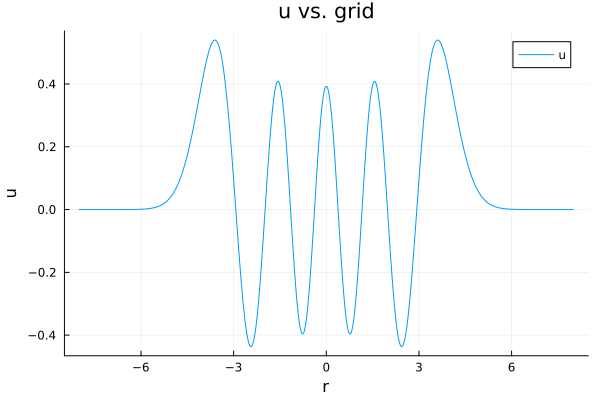

In [2]:
    r_min::Float64=-8.0; #Where the space grid starts.
    r_max::Float64=8.0; #Where the space grid ends.
    N=20000; #Number of points in the space grind.
    grid_stru= Grids.UniformGrid(r_min, r_max, N); #Grid creation, grid is the list with the grid points.
    grid= grid_stru.grid;
    initial_condition_function_x_min = InitialConditions.exponential_decay_at_r_ref;
    initial_condition_function_x_max = InitialConditions.exponential_decay_at_r_ref;

    w::Float64=1;
    m::Float64=1;
    l=0;
    v_effe= Potentials.harmoic_oscilator_potential(w,m,grid_stru.grid); #the list with the quantum harmonic oscillator potential

    #Energy grid definition and creation. The system searches the energy grid for potential 
    #values for the eigenvalues of the Schrodinger equation 
    E_max::Float64=8.7; #Maximal energy in the energy grid.
    E_min::Float64=0.4; #Minimal energy in the energy grid.
    E_N::Int64=200; #Number of points in the energy grid.
    E_grid_stru= Grids.UniformGrid(E_min, E_max, E_N); #List with the energy grid points.
    energy_grid= E_grid_stru.grid;
    E_intervals= EigenvalueFinders.find_eigenvalue_intervals(energy_grid, v_effe, grid_stru,
        initial_condition_function_x_min,
        initial_condition_function_x_max,
        l);
    numb_solu::Int64= size(E_intervals)[1]; #Number of potential solutions in the energy grid.
    eigen_list::Vector{Float64}=zeros(numb_solu); #Initializing the list that is going to hold the energy eigenvalues.
    u_wave_functions::Vector{Vector{Float64}}= [zeros(N) for _ in 1:numb_solu]; #Initializing the list that holds the eigenfunctions list.

    #Using Illinois algorithm to find the actual energy eigenvalue and eigenfunction for everyone of the energy intervals.
    for (i, i_E_interval) in enumerate(E_intervals)
        u_temp, ei_temp= EigenvalueFinders.illinois_eigenvalue_finder(i_E_interval,
        v_effe, grid_stru, 
        initial_condition_function_x_min,
        initial_condition_function_x_max,l);
        u_wave_functions[i]=u_temp;
        eigen_list[i]= ei_temp;
    end

    for (i,i_E_interval) in enumerate(E_intervals)
    println("E_min= ", i_E_interval[1], " E_max= ", i_E_interval[2]);
    u,i_E= EigenvalueFinders.illinois_eigenvalue_finder(i_E_interval,
    v_effe, grid_stru, 
    initial_condition_function_x_min,
    initial_condition_function_x_max,l)
    println("E= ", i_E);
    p= plot(   
        grid,
        u,
        label="u",
        xlabel="r",
        ylabel="u",
        title="u vs. grid"
    )
    display(p)
end